---
# FASTER R-CNN
---

# 0-) IMPORTS

In [2]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from sklearn.model_selection import train_test_split
from collections import defaultdict
from pathlib import Path

In [3]:
gpus = tf.config.list_physical_devices('GPU')

tf.config.set_visible_devices(gpus[0], 'GPU')

from tensorflow.python.client import device_lib
print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')), "\n")

# Tüm cihazları listele ve her cihazın türünü yazdır
local_devices = device_lib.list_local_devices()

for device in local_devices:
    print(f"Device Name: {device.name}")
    print(f"Device Type: {device.device_type}")
    print(f"Device Description: {device.physical_device_desc}")
    print("-" * 40)

TensorFlow Version: 2.10.0
Num GPUs Available:  2 

Device Name: /device:CPU:0
Device Type: CPU
Device Description: 
----------------------------------------
Device Name: /device:GPU:0
Device Type: GPU
Device Description: device: 0, name: DML, pci bus id: <undefined>
----------------------------------------
Device Name: /device:GPU:1
Device Type: GPU
Device Description: device: 1, name: DML, pci bus id: <undefined>
----------------------------------------


# 1-)Data Preprocessing

In [4]:
def plot_images(images, bboxes, class_names, n=5):
    plt.figure(figsize=(20, 10))
    for i in range(min(n, len(images))):
        img = images[i].copy()
        # Skip if no boxes
        if not bboxes[i]:
            continue        
        # Ensure image is in valid format
        if img.dtype != np.uint8:
            img = img.astype(np.uint8)
            
        # Convert grayscale to BGR if needed
        if len(img.shape) == 2 or img.shape[2] == 1:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            
        # Ensure color conversion safety
        try:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        except cv2.error:
            print(f"Invalid image at index {i} - shape: {img.shape}, dtype: {img.dtype}")
            continue
            
        # Draw bounding boxes
        for (class_id, xmin, ymin, xmax, ymax) in bboxes[i]:
            color = (0,255,0) if class_id == 0 else (0,0,255)
            # Convert coordinates to integers
            xmin, ymin, xmax, ymax = map(int, (xmin, ymin, xmax, ymax))
            cv2.rectangle(img_rgb, (xmin, ymin), (xmax, ymax), color, 2)
            cv2.putText(img_rgb, class_names[class_id], (xmin, ymin-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
            
        plt.subplot(1, n, i+1)
        plt.imshow(img_rgb)
        plt.axis('off')
    plt.show()

In [5]:
def validate_box(box, img_width, img_height):
    """Ensure box coordinates are within image dimensions and valid."""
    # Check box format
    if len(box) != 5:
        raise ValueError(f"Invalid box format. Expected 5 elements, got {len(box)}")
    
    class_id = box[0]
    xmin = np.clip(box[1], 0, img_width-1)
    ymin = np.clip(box[2], 0, img_height-1)
    xmax = np.clip(box[3], xmin+1, img_width)
    ymax = np.clip(box[4], ymin+1, img_height)
    
    # Convert to integers
    xmin, ymin, xmax, ymax = map(int, (xmin, ymin, xmax, ymax))
    
    # Handle edge cases
    if xmax - xmin < 2 or ymax - ymin < 2:
        cx = img_width // 2
        cy = img_height // 2
        return [class_id, cx-1, cy-1, cx+1, cy+1]
        
    return [class_id, xmin, ymin, xmax, ymax]

In [6]:
#Data Loading with Proper BBox Handling
def load_dataset(img_dir, annot_dir, target_size=(416, 416)):
    images = []
    annotations = []
    class_names = {0: 'helmet', 1: 'head'}
    
    # Parse XML annotations
    for xml_file in Path(annot_dir).glob('*.xml'):
        tree = ET.parse(xml_file)
        root = tree.getroot()
        
        # Image loading
        img_path = Path(img_dir) / root.find('filename').text
        img = cv2.imread(str(img_path))
        orig_h, orig_w = img.shape[:2]
        
        # Resize image and calculate scale factors
        img = cv2.resize(img, target_size)
        new_w, new_h = target_size
        w_scale = new_w / orig_w
        h_scale = new_h / orig_h
        
        # Parse and scale bounding boxes
        bboxes = []
        for obj in root.findall('object'):
            class_name = obj.find('name').text.lower()
            class_id = 0 if 'helmet' in class_name else 1
            bndbox = obj.find('bndbox')
            xmin = int(float(bndbox.find('xmin').text) * w_scale)
            ymin = int(float(bndbox.find('ymin').text) * h_scale)
            xmax = int(float(bndbox.find('xmax').text) * w_scale)
            ymax = int(float(bndbox.find('ymax').text) * h_scale)
            validated_box = validate_box([class_id, xmin, ymin, xmax, ymax],
                                          img_width=target_size[0],
                                          img_height=target_size[1])
            bboxes.append(validated_box)
        
        images.append(img)
        annotations.append(bboxes)
    
    print(f"Loaded {len(images)} images with {sum(len(b) for b in annotations)} annotations")
    return np.array(images), annotations, class_names

Loaded 5000 images with 25502 annotations


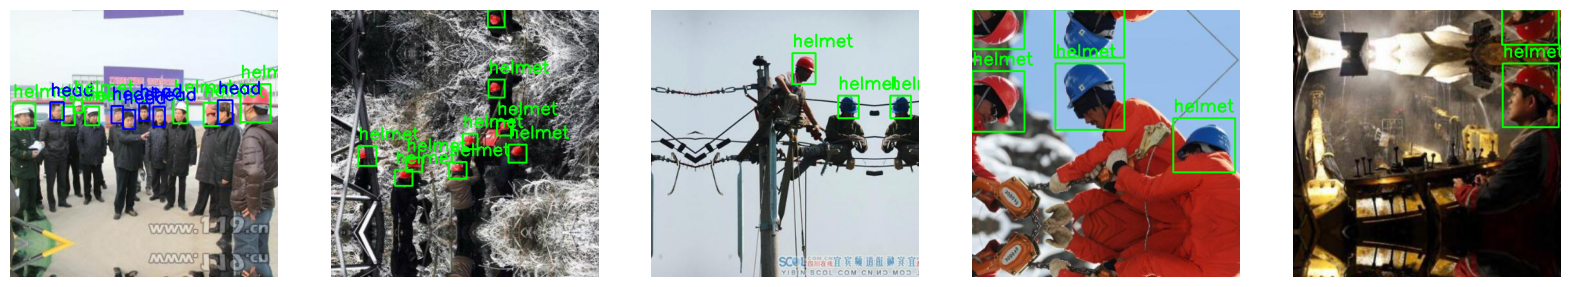

In [7]:
# Load and visualize raw data
images, annotations, class_names = load_dataset("Dataset/images", "Dataset/annotations")
plot_images(images, annotations, class_names)

In [8]:
#Train-Val-Test Split with Visualization
def split_data(images, annotations, test_size=0.2, val_size=0.2):
    # First split: train+val vs test
    X_train, X_test, y_train, y_test = train_test_split(
        images, annotations, test_size=test_size, random_state=42)
    
    # Second split: train vs val
    val_size_adj = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=val_size_adj, random_state=42)
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

In [9]:
# Split and visualize
train_data, val_data, test_data = split_data(images, annotations)
print("Train:", len(train_data[0]), "Val:", len(val_data[0]), "Test:", len(test_data[0]))

Train: 3000 Val: 1000 Test: 1000



Train Samples:


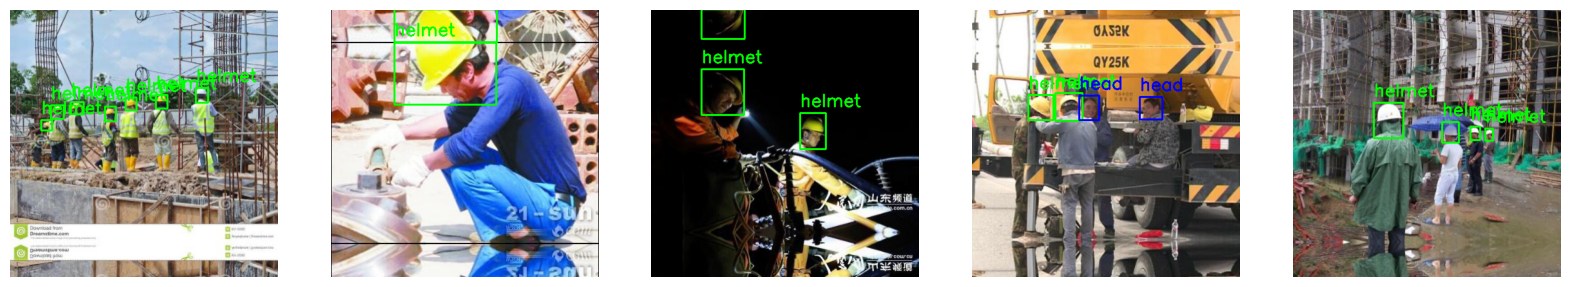


Validation Samples:


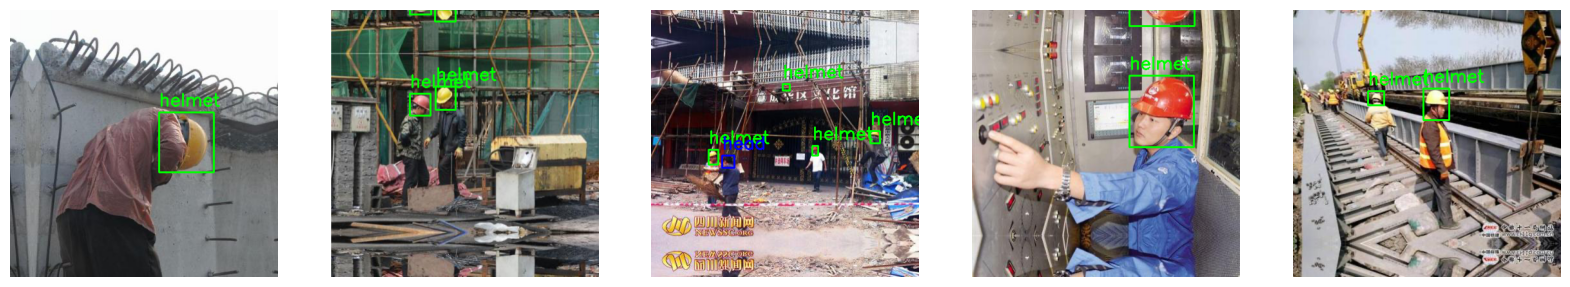


Test Samples:


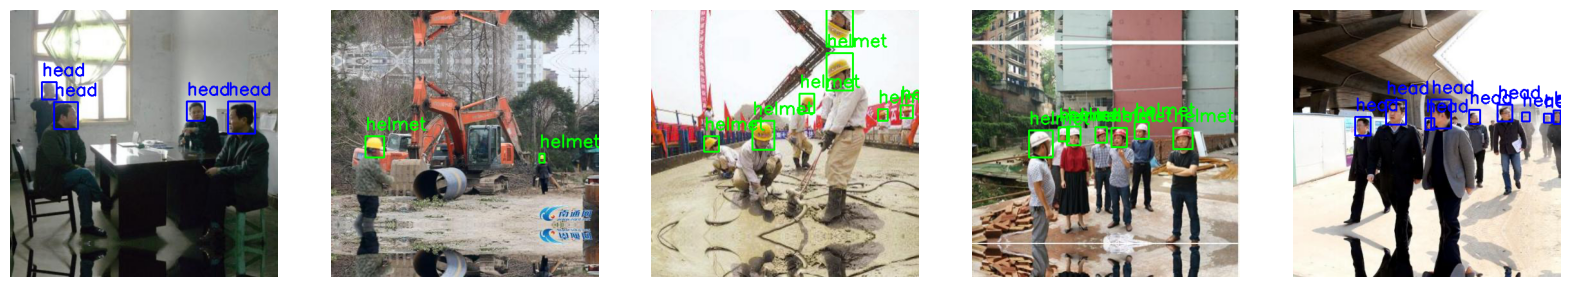

In [10]:
print("\nTrain Samples:")
plot_images(train_data[0], train_data[1], class_names)
print("\nValidation Samples:")
plot_images(val_data[0], val_data[1], class_names)
print("\nTest Samples:")
plot_images(test_data[0], test_data[1], class_names)

In [11]:
#Data Augmentation with BBox Awareness
class DataAugmenter:
    def __init__(self, target_size=(416, 416)):
        self.target_size = target_size
        
    def random_flip(self, image, bboxes):
        if np.random.rand() < 0.5:
            image = cv2.flip(image, 1)
            for i in range(len(bboxes)):
                _, xmin, ymin, xmax, ymax = bboxes[i]
                new_xmin = self.target_size[0] - xmax
                new_xmax = self.target_size[0] - xmin
                bboxes[i][1] = new_xmin
                bboxes[i][3] = new_xmax
        return image, bboxes
    
    def random_zoom(self, image, bboxes, min_zoom=0.8, max_zoom=1.2):
        zoom = np.random.uniform(min_zoom, max_zoom)
        h, w = image.shape[:2]

        try:
            # Resize the image
            new_h, new_w = int(h * zoom), int(w * zoom)
            resized = cv2.resize(image, (new_w, new_h))

            # Handle zoom-in (cropping)
            if zoom > 1.0:
                start_x = max(0, (new_w - w) // 2)
                start_y = max(0, (new_h - h) // 2)
                end_x = start_x + w
                end_y = start_y + h
                resized = resized[start_y:end_y, start_x:end_x]

                # Adjust bounding boxes
                for i in range(len(bboxes)):
                    bboxes[i][1] = (bboxes[i][1] * zoom) - start_x
                    bboxes[i][3] = (bboxes[i][3] * zoom) - start_x
                    bboxes[i][2] = (bboxes[i][2] * zoom) - start_y
                    bboxes[i][4] = (bboxes[i][4] * zoom) - start_y

            # Handle zoom-out (padding)
            else:
                delta_w = w - new_w
                delta_h = h - new_h
                top = delta_h // 2
                bottom = delta_h - top
                left = delta_w // 2
                right = delta_w - left

                resized = cv2.copyMakeBorder(resized, 
                                            top, bottom, 
                                            left, right, 
                                            cv2.BORDER_CONSTANT)

                # Adjust bounding boxes
                for i in range(len(bboxes)):
                    bboxes[i][1] = (bboxes[i][1] * zoom) + left
                    bboxes[i][3] = (bboxes[i][3] * zoom) + left
                    bboxes[i][2] = (bboxes[i][2] * zoom) + top
                    bboxes[i][4] = (bboxes[i][4] * zoom) + top

            # Ensure final size matches target
            final = cv2.resize(resized, (w, h))

            # Scale bounding boxes to original dimensions
            scale_x = w / new_w if zoom < 1 else 1.0
            scale_y = h / new_h if zoom < 1 else 1.0

            # Modify the final scaling step
            for i in range(len(bboxes)):
                bboxes[i][1] = int(np.clip(bboxes[i][1] * scale_x, 0, w-1))
                bboxes[i][3] = int(np.clip(bboxes[i][3] * scale_x, 0, w-1))
                bboxes[i][2] = int(np.clip(bboxes[i][2] * scale_y, 0, h-1))
                bboxes[i][4] = int(np.clip(bboxes[i][4] * scale_y, 0, h-1))            
                
            return final, bboxes
    
        except Exception as e:
            print(f"Zoom augmentation failed: {e}")
            return image.copy(), [b.copy() for b in bboxes]
    
    def augment(self, image, bboxes):
        image, bboxes = self.random_flip(image, bboxes)
        image, bboxes = self.random_zoom(image, bboxes)
        # Add post-augmentation validation
        validated_bboxes = []
        for bbox in bboxes:
            validated_bboxes.append(
                validate_box(bbox, 
                             img_width=image.shape[1], 
                             img_height=image.shape[0])
            )
        return image, validated_bboxes

Augmented Samples:


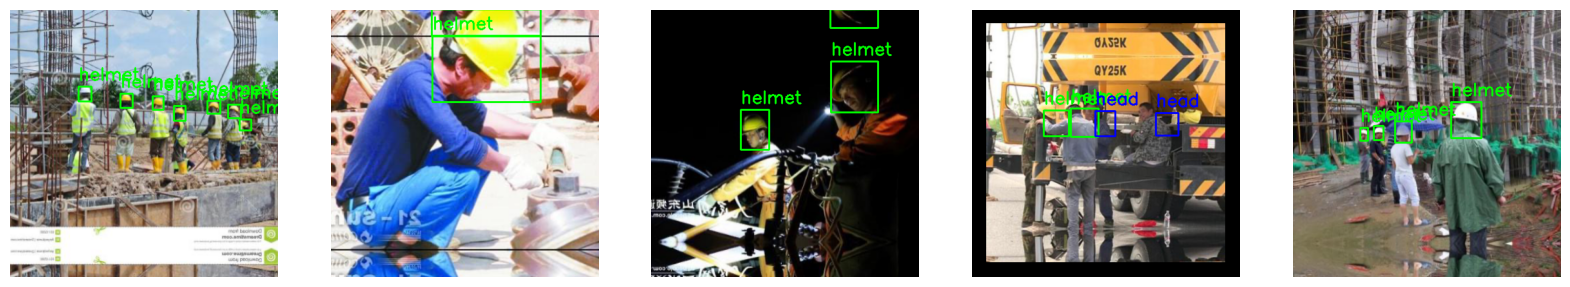

In [12]:
# Testing augmentation
augmenter = DataAugmenter()
aug_images, aug_bboxes = [], []

for img, bboxes in zip(train_data[0][:5], train_data[1][:5]):
    aug_img, aug_bbox = augmenter.augment(img.copy(), [b.copy() for b in bboxes])
    aug_images.append(aug_img)
    aug_bboxes.append(aug_bbox)

print("Augmented Samples:")
plot_images(aug_images, aug_bboxes, class_names)

In [13]:
# Data Generator (Updated)
class DetectionDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, images, annotations, batch_size=8, augment=False, max_objects=None):
        self.images = images
        self.annotations = annotations
        self.batch_size = batch_size
        self.augment = augment
        self.augmenter = DataAugmenter()
        
        # Calculate maximum objects in the dataset
        # Use provided max_objects or calculate from annotations
        self.max_objects = max_objects if max_objects is not None else max(len(b) for b in annotations)
        print(f"Maximum objects per image: {self.max_objects}")
        
    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))
    
    def __getitem__(self, idx):
        batch_images = []
        batch_bboxes = []
        batch_classes = []
        
        for i in range(idx*self.batch_size, (idx+1)*self.batch_size):
            if i >= len(self.images): break
            
            img = self.images[i]
            bboxes = self.annotations[i]
            
            if self.augment:
                img, bboxes = self.augmenter.augment(img.copy(), bboxes.copy())
            
            # Normalize image
            img = img / 255.0
            
            # Convert annotations to output format
            classes = np.array([b[0] for b in bboxes], dtype=np.int32)
            boxes = np.array([b[1:] for b in bboxes], dtype=np.float32)
            
            # Validation checks
            assert boxes.shape[1] == 4, "Boxes should have 4 coordinates"
            assert classes.shape[0] == boxes.shape[0], "Mismatch between class and box counts"
            
            batch_images.append(img)
            batch_classes.append(classes)
            batch_bboxes.append(boxes)
        
        # Pad sequences to fixed length
        padded_classes = []
        padded_boxes = []
        
        for cls, boxes in zip(batch_classes, batch_bboxes):
            pad_count = self.max_objects - len(cls)
            
            padded_classes.append(
                np.pad(cls, (0, pad_count), 
                mode='constant', 
                constant_values=-1)
            )
            
            padded_boxes.append(
                np.pad(boxes, [(0, pad_count), (0, 0)], 
                mode='constant', 
                constant_values=0)
            )
        
        return np.array(batch_images), [np.array(padded_classes), np.array(padded_boxes)]

In [14]:
# Create generators with consistent max_objects

# Calculate max_objects from full dataset
max_objects = max(len(bboxes) for bboxes in annotations)

train_gen = DetectionDataGenerator(train_data[0], train_data[1], 
                                 max_objects=max_objects, augment=True)
val_gen = DetectionDataGenerator(val_data[0], val_data[1], 
                                max_objects=max_objects)
test_gen = DetectionDataGenerator(test_data[0], test_data[1], 
                                 max_objects=max_objects)

Maximum objects per image: 68
Maximum objects per image: 68
Maximum objects per image: 68


Batch shapes: (8, 416, 416, 3) (8, 68) (8, 68, 4)


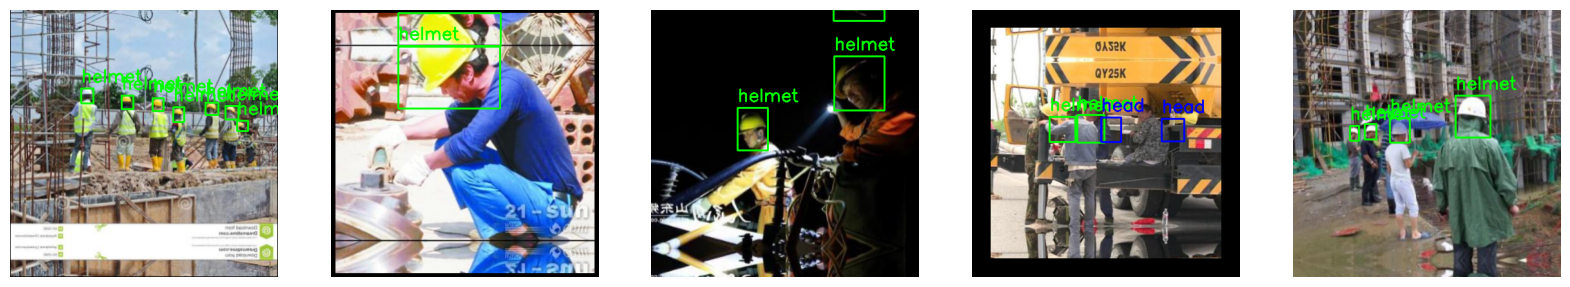

In [15]:
# Visualize generator output
sample_batch = train_gen[0]

# Convert images to proper format
display_images = (sample_batch[0] * 255).astype(np.uint8)

# Convert boxes to proper format
display_boxes = []
for cls, boxes in zip(sample_batch[1][0], sample_batch[1][1]):  # Access list indices instead of dict keys
    image_boxes = []
    for c, b in zip(cls, boxes):
        if c != -1:  # Filter out padding
            image_boxes.append((int(c),) + tuple(b.astype(int)))
    display_boxes.append(image_boxes)

print("Batch shapes:", 
      sample_batch[0].shape,  # Images
      sample_batch[1][0].shape,  # Classes
      sample_batch[1][1].shape)  # Boxes

plot_images(display_images, display_boxes, class_names)

In [16]:
# Sample batch check
sample_batch = train_gen[0]
print("Image batch shape:", sample_batch[0].shape)          # Should be (batch, 416, 416, 3)
print("Class targets shape:", sample_batch[1][0].shape)     # Should be (batch, max_objects)
print("Box targets shape:", sample_batch[1][1].shape)       # Should be (batch, max_objects, 4)

Image batch shape: (8, 416, 416, 3)
Class targets shape: (8, 68)
Box targets shape: (8, 68, 4)


# 2-) MODELLING

In [17]:
# First install TensorFlow Addons if needed
#!pip install tensorflow-addons

In [18]:
import tensorflow_addons as tfa

# 2-) COMPLETE FASTER R-CNN IMPLEMENTATION
class AnchorGenerator:
    def __init__(self, scales=[32, 64, 128], ratios=[0.5, 1, 2], feature_stride=16):
        self.scales = scales
        self.ratios = ratios
        self.feature_stride = feature_stride
        
    def generate_anchors(self, feature_map_size):
        heights, widths = feature_map_size
        anchors = []
        for y in range(heights):
            for x in range(widths):
                center_x = (x + 0.5) * self.feature_stride
                center_y = (y + 0.5) * self.feature_stride
                for scale in self.scales:
                    for ratio in self.ratios:
                        w = scale * np.sqrt(ratio)
                        h = scale / np.sqrt(ratio)
                        anchors.append([
                            center_x - w/2,  # xmin
                            center_y - h/2,  # ymin
                            center_x + w/2,  # xmax
                            center_y + h/2   # ymax
                        ])
        return np.array(anchors, dtype=np.float32)

class ProposalLayer(tf.keras.layers.Layer):
    def __init__(self, num_proposals=300, **kwargs):
        super().__init__(**kwargs)
        self.num_proposals = num_proposals
        
    def call(self, inputs):
        scores, deltas, anchors = inputs
        batch_size = tf.shape(scores)[0]
        
        # Reshape RPN outputs
        scores = tf.reshape(scores, [batch_size, -1])  # (B, H*W*A)
        deltas = tf.reshape(deltas, [batch_size, -1, 4])  # (B, H*W*A, 4)
        
        # Calculate anchor dimensions
        widths = anchors[:, 2] - anchors[:, 0]
        heights = anchors[:, 3] - anchors[:, 1]
        centers_x = anchors[:, 0] + 0.5 * widths
        centers_y = anchors[:, 1] + 0.5 * heights

        # Expand dimensions for broadcasting
        centers_x = tf.expand_dims(centers_x, axis=0)  # (1, num_anchors)
        centers_y = tf.expand_dims(centers_y, axis=0)
        widths = tf.expand_dims(widths, axis=0)
        heights = tf.expand_dims(heights, axis=0)

        # Apply deltas to all anchors
        dx = deltas[..., 0]
        dy = deltas[..., 1]
        dw = deltas[..., 2]
        dh = deltas[..., 3]

        pred_centers_x = centers_x + dx * widths
        pred_centers_y = centers_y + dy * heights
        pred_widths = widths * tf.exp(dw)
        pred_heights = heights * tf.exp(dh)

        # Convert to (xmin, ymin, xmax, ymax)
        proposals = tf.stack([
            pred_centers_x - 0.5 * pred_widths,
            pred_centers_y - 0.5 * pred_heights,
            pred_centers_x + 0.5 * pred_widths,
            pred_centers_y + 0.5 * pred_heights
        ], axis=-1)

        # Clip proposals to image boundaries
        proposals = tf.clip_by_value(proposals, 0, 416)

        # Select top proposals across all anchors
        top_k_scores, top_k_indices = tf.math.top_k(scores, k=self.num_proposals)
        
        # Gather top proposals using indices
        proposals = tf.gather(proposals, top_k_indices, batch_dims=1)
        
        return proposals, top_k_scores

class ROIAlignLayer(tf.keras.layers.Layer):
    def __init__(self, crop_size=(7, 7), num_rois=300, **kwargs):
        super().__init__(**kwargs)
        self.crop_size = crop_size
        self.num_rois = num_rois

    def call(self, inputs):
        feature_map, proposals = inputs
        batch_size = tf.shape(feature_map)[0]
        
        # Convert proposals to normalized coordinates (y1, x1, y2, x2)
        # Proposals shape: (batch_size, num_rois, 4) in image coordinates (0-416)
        image_size = 416.0
        feature_stride = 32.0  # For ResNet50 conv5_block3_out
        
        # Normalize coordinates to feature map space (13x13 grid)
        boxes = proposals / feature_stride / (image_size / feature_stride)  # Normalize to [0, 1]
        
        # Convert to (y1, x1, y2, x2) format
        boxes = tf.stack([
            boxes[..., 1],  # y1
            boxes[..., 0],  # x1
            boxes[..., 3],  # y2
            boxes[..., 2],  # x2
        ], axis=-1)
        
        # Create batch indices [0,0,...,1,1,...,2,2,...]
        box_indices = tf.tile(
            tf.range(batch_size, dtype=tf.int32)[:, tf.newaxis],
            [1, self.num_rois]
        )
        box_indices = tf.reshape(box_indices, [-1])
        
        # Reshape for crop_and_resize
        boxes = tf.reshape(boxes, [-1, 4])
        
        # Perform crop and resize
        cropped = tf.image.crop_and_resize(
            feature_map,
            boxes,
            box_indices,
            self.crop_size,
            method='bilinear'
        )
        
        # Reshape to (batch_size, num_rois, height, width, channels)
        final_shape = (batch_size, self.num_rois, self.crop_size[0], self.crop_size[1], feature_map.shape[-1])
        return tf.reshape(cropped, final_shape)

# Modified Faster R-CNN builder
def build_faster_rcnn(input_shape=(416, 416, 3), num_classes=2):
    # Backbone Network
    backbone = tf.keras.applications.ResNet50(
        include_top=False, 
        input_shape=input_shape,
        weights='imagenet'
    )
    c5_output = backbone.get_layer("conv5_block3_out").output
    
    # Region Proposal Network (RPN)
    rpn = tf.keras.layers.Conv2D(512, (3,3), padding='same', activation='relu')(c5_output)
    rpn_cls = tf.keras.layers.Conv2D(9, (1,1), activation='sigmoid', name='rpn_cls')(rpn)
    rpn_reg = tf.keras.layers.Conv2D(9*4, (1,1), activation='linear', name='rpn_reg')(rpn)

    # Generate anchors and proposals
    anchor_generator = AnchorGenerator()
    anchors = anchor_generator.generate_anchors((c5_output.shape[1], c5_output.shape[2]))
    anchors = tf.convert_to_tensor(anchors, dtype=tf.float32)
    proposals, _ = ProposalLayer(num_proposals=300)([rpn_cls, rpn_reg, anchors])

    # Custom ROI Align
    roi_pooling = ROIAlignLayer(crop_size=(7,7), num_rois=300)([c5_output, proposals])

    # Detection Network
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(roi_pooling)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1024, activation='relu'))(x)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Dropout(0.3))(x)
    
    # Output heads
    cls_output = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(num_classes, activation='softmax'),
        name='classification'
    )(x)
    
    reg_output = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(4, activation='linear'),
        name='regression'
    )(x)

    return tf.keras.Model(
        inputs=backbone.input, 
        outputs=[rpn_cls, rpn_reg, cls_output, reg_output]
    )

# Build and verify
frcnn = build_faster_rcnn()
frcnn.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 416, 416, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 422, 422, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 208, 208, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                              

In [19]:
#Verify Output Names
print(frcnn.output_names)  # Should show ['class_output', 'box_output']

['rpn_cls', 'rpn_reg', 'classification', 'regression']


In [20]:
# 4-) TARGET GENERATION
class RPNTargetGenerator:
    def __init__(self, num_anchors=9, positive_iou=0.7, negative_iou=0.3):
        self.num_anchors = num_anchors
        self.positive_iou = positive_iou
        self.negative_iou = negative_iou
        
    def generate_targets(self, anchors, gt_boxes):
        ious = self.compute_iou(anchors, gt_boxes)
        max_ious = np.max(ious, axis=1)
        
        # Assign labels
        labels = np.zeros((len(anchors),))
        labels[max_ious >= self.positive_iou] = 1  # Positive
        labels[max_ious < self.negative_iou] = -1   # Negative
        
        # Calculate regression targets
        gt_assigned = np.argmax(ious, axis=1)
        gt_boxes_assigned = gt_boxes[gt_assigned]
        reg_targets = self.compute_regression(anchors, gt_boxes_assigned)
        
        return labels, reg_targets
    
    def compute_iou(self, boxes1, boxes2):
        # Implementation of IoU calculation
        pass
    
    def compute_regression(self, anchors, gt_boxes):
        # Implementation of regression target calculation
        pass

In [22]:
# RPN Classification Loss (Binary Crossentropy)
class RPNClassLoss(tf.keras.losses.Loss):
    def __init__(self):
        super().__init__()
        self.cls_loss = tf.keras.losses.BinaryCrossentropy()
        
    def call(self, y_true, y_pred):
        valid_mask = tf.not_equal(y_true, -1)
        return self.cls_loss(
            tf.boolean_mask(y_true, valid_mask),
            tf.boolean_mask(y_pred, valid_mask)
        )

# RPN Regression Loss (Huber)
class RPNRegLoss(tf.keras.losses.Loss):
    def __init__(self):
        super().__init__()
        self.reg_loss = tf.keras.losses.Huber()
        
    def call(self, y_true, y_pred):
        pos_mask = tf.reduce_any(tf.not_equal(y_true, 0), axis=-1)
        return self.reg_loss(
            tf.boolean_mask(y_true, pos_mask),
            tf.boolean_mask(y_pred, pos_mask)
        )

# Fast R-CNN Classification Loss
class FRCNNClassLoss(tf.keras.losses.Loss):
    def __init__(self):
        super().__init__()
        self.cls_loss = tf.keras.losses.SparseCategoricalCrossentropy()
        
    def call(self, y_true, y_pred):
        valid_mask = tf.not_equal(y_true, -1)
        return self.cls_loss(
            tf.boolean_mask(y_true, valid_mask),
            tf.boolean_mask(y_pred, valid_mask)
        )

# Fast R-CNN Regression Loss
class FRCNNRegLoss(tf.keras.losses.Loss):
    def __init__(self):
        super().__init__()
        self.reg_loss = tf.keras.losses.Huber()
        
    def call(self, y_true, y_pred):
        pos_mask = tf.reduce_any(tf.not_equal(y_true, 0), axis=-1)
        return self.reg_loss(
            tf.boolean_mask(y_true, pos_mask),
            tf.boolean_mask(y_pred, pos_mask)
        )

In [23]:
frcnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss={
        'rpn_cls': RPNClassLoss(),  # Handles only classification targets
        'rpn_reg': RPNRegLoss(),    # Handles only regression targets
        'classification': FRCNNClassLoss(),
        'regression': FRCNNRegLoss()
    },
    loss_weights={
        'rpn_cls': 1.0,
        'rpn_reg': 1.0,
        'classification': 1.0,
        'regression': 1.0
    }
)

In [24]:
# Sample output structure from generator
{
    'rpn_cls': rpn_class_targets,        # Shape: (batch_size, num_anchors)
    'rpn_reg': rpn_regression_targets,   # Shape: (batch_size, num_anchors, 4)
    'classification': frcnn_class_ids,   # Shape: (batch_size, max_objects)
    'regression': frcnn_box_targets      # Shape: (batch_size, max_objects, 4)
}

NameError: name 'rpn_class_targets' is not defined

In [26]:
class ProposalLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        scores, deltas, anchors = inputs
        batch_size = tf.shape(scores)[0]
        
        # Reshape scores & deltas to match anchors
        scores = tf.reshape(scores, [batch_size, -1])
        deltas = tf.reshape(deltas, [batch_size, -1, 4])
        
        # Process each sample in batch
        proposals_batch = []
        for i in range(batch_size):
            # Apply deltas to anchors
            widths = anchors[:, 2] - anchors[:, 0]
            centers_x = anchors[:, 0] + 0.5 * widths
            
            # ... rest of transformation logic ...
            
            proposals_batch.append(transformed_boxes)
            
        return tf.stack(proposals_batch, axis=0)

In [27]:
# 5-) REVISED CUSTOM LOSSES
class RPNLoss(tf.keras.losses.Loss):
    def __init__(self, lambda_rpn=1.0):
        super().__init__()
        self.lambda_rpn = lambda_rpn
        self.cls_loss = tf.keras.losses.BinaryCrossentropy()
        self.reg_loss = tf.keras.losses.Huber()
        
    def call(self, y_true, y_pred):
        # Proper tensor unpacking
        labels = y_true[..., 0]  # Classification labels
        reg_targets = y_true[..., 1:5]  # Regression targets
        
        # Split RPN predictions
        cls_pred = y_pred[0]
        reg_pred = y_pred[1]

        # Classification loss (ignore -1 labels)
        valid_mask = tf.not_equal(labels, -1)
        cls_loss = self.cls_loss(
            tf.boolean_mask(labels, valid_mask),
            tf.boolean_mask(cls_pred, valid_mask)
        )

        # Regression loss (only positive anchors)
        pos_mask = tf.equal(labels, 1)
        reg_loss = self.reg_loss(
            tf.boolean_mask(reg_targets, pos_mask),
            tf.boolean_mask(reg_pred, pos_mask)
        )

        return cls_loss + self.lambda_rpn * reg_loss

class FastRCNNLoss(tf.keras.losses.Loss):
    def __init__(self, num_classes):
        super().__init__()
        self.cls_loss = tf.keras.losses.SparseCategoricalCrossentropy()
        self.reg_loss = tf.keras.losses.Huber()
        
    def call(self, y_true, y_pred):
        # Split inputs
        class_ids = y_true[0]
        box_targets = y_true[1]
        cls_pred = y_pred[0]
        reg_pred = y_pred[1]

        # Classification loss
        cls_loss = self.cls_loss(class_ids, cls_pred)

        # Regression loss (only for positive classes)
        mask = tf.cast(class_ids > 0, tf.float32)
        reg_loss = self.reg_loss(box_targets * mask[..., tf.newaxis], reg_pred)

        return cls_loss + reg_loss

# 6-) REVISED DATA GENERATOR
class DetectionDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, images, annotations, anchor_generator, batch_size=8):
        self.images = images
        self.annotations = annotations
        self.batch_size = batch_size
        self.anchor_gen = anchor_generator
        self.rpn_target_gen = RPNTargetGenerator()

    def __getitem__(self, idx):
        batch_images = []
        rpn_cls_targets = []
        rpn_reg_targets = []
        rcnn_cls_targets = []
        rcnn_reg_targets = []

        for i in range(idx*self.batch_size, (idx+1)*self.batch_size):
            if i >= len(self.images): break
            
            img = self.images[i]
            gt_boxes = self.annotations[i]
            
            # Convert boxes to format: [N, (class_id, x1, y1, x2, y2)]
            gt_boxes = np.array([b for b in gt_boxes if b[0] != -1])
            
            # Generate RPN targets
            anchors = self.anchor_gen.generate_anchors()
            rpn_labels, rpn_reg = self.rpn_target_gen.generate_targets(anchors, gt_boxes)
            
            # Store targets
            batch_images.append(img)
            rpn_cls_targets.append(rpn_labels)
            rpn_reg_targets.append(rpn_reg)
            
            # For Faster R-CNN (simplified example)
            rcnn_cls_targets.append(gt_boxes[:, 0])
            rcnn_reg_targets.append(gt_boxes[:, 1:5])

        # Pad sequences
        return (
            np.array(batch_images),
            {
                'rpn_cls': np.array(rpn_cls_targets),
                'rpn_reg': np.array(rpn_reg_targets),
                'classification': np.array(rcnn_cls_targets),
                'regression': np.array(rcnn_reg_targets)
            }
        )

# 7-) COMPILE WITH PROPER TARGET MAPPING
frcnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss={
        'rpn_cls': RPNLoss(),
        'rpn_reg': RPNLoss(),
        'classification': FastRCNNLoss(num_classes=2),
        'regression': FastRCNNLoss(num_classes=2)
    },
    loss_weights={
        'rpn_cls': 1.0,
        'rpn_reg': 1.0,
        'classification': 1.0,
        'regression': 1.0
    }
)

# 8-) TRAIN THE MODEL
history = frcnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint('frcnn_best.h5', save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
    ]
)

Epoch 1/20


ValueError: in user code:

    File "c:\Users\Giray\Projects\Safety_Helmet_Object_Detection\tensorflow_env\lib\site-packages\keras\engine\training.py", line 1160, in train_function  *
        return step_function(self, iterator)
    File "c:\Users\Giray\Projects\Safety_Helmet_Object_Detection\tensorflow_env\lib\site-packages\keras\engine\training.py", line 1146, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "c:\Users\Giray\Projects\Safety_Helmet_Object_Detection\tensorflow_env\lib\site-packages\keras\engine\training.py", line 1135, in run_step  **
        outputs = model.train_step(data)
    File "c:\Users\Giray\Projects\Safety_Helmet_Object_Detection\tensorflow_env\lib\site-packages\keras\engine\training.py", line 998, in train_step
        return self.compute_metrics(x, y, y_pred, sample_weight)
    File "c:\Users\Giray\Projects\Safety_Helmet_Object_Detection\tensorflow_env\lib\site-packages\keras\engine\training.py", line 1092,

In [ ]:
# 8-) INFERENCE
def predict_and_visualize(model, test_images, class_names):
    # Generate predictions
    rpn_cls, rpn_reg, cls_pred, reg_pred = model.predict(test_images)
    
    # Post-process predictions
    final_boxes = []
    final_scores = []
    final_labels = []
    
    for i in range(len(test_images)):
        # Select top N proposals
        scores = rpn_cls[i].flatten()
        top_indices = np.argsort(scores)[::-1][:100]
        
        # Apply regression offsets
        anchors = AnchorGenerator().generate_anchors(feature_map_size=(16, 16))
        proposals = self.apply_regression(anchors[top_indices], rpn_reg[i][top_indices])
        
        # Non-max suppression
        selected_indices = tf.image.non_max_suppression(
            proposals, scores[top_indices], 50, iou_threshold=0.5)
        
        final_boxes.append(proposals[selected_indices])
        final_scores.append(scores[selected_indices])
        final_labels.append(np.argmax(cls_pred[i][selected_indices], axis=1))
    
    # Visualize results
    plot_images(test_images, final_boxes, class_names)

# Usage
test_images = test_data[0][:5]
predict_and_visualize(frcnn, test_images, class_names)

1/1 [==============================] - 1s 1s/step


NameError: name 'self' is not defined